# Drive and utilities


In [1]:
#@title Mount Drive to get BERT model
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [2]:
#@title Utils
!pip install dill
!pip install pandas
!pip install numpy
!
import dill as pickle

def load(filename):
    with open(filename, 'rb') as f:
        return pickle.load(f)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 3.5 MB/s eta 0:00:00


# Matching

## Matching on pre-treatment outcomes only - GPU based

In [ ]:
#@title Load Data

!pip install numpy pandas scipy scikit-learn sklearn tqdm cudf cupy

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm import tqdm
from scipy import stats
import cudf
import cudf
import cupy as cp

## Load
citations = cudf.read_parquet("/content/drive/MyDrive/PhD Data/08 Citations/02 Patent citations - raw.parquet")
acquired_patents_pd = pd.read_pickle("/content/drive/MyDrive/PhD Data/10 Sample - pre final/acquired_patents.pkl")  # if small, you can load as cuDF
potential_controls_pd = pd.read_pickle("/content/drive/MyDrive/PhD Data/10 Sample - pre final/potential_controls.pkl")

## Remove GAFAM patents
clean_potential_ids = pd.read_csv("/content/drive/MyDrive/PhD Data/10 Sample - pre final/clean_potential_control_ids.csv")
clean_set = set(clean_potential_ids['patent_id'].astype(str))


# If embeddings are lists of floats and you want to preserve them,
# you might convert each to a string representation or drop them if not needed.
# Convert columns to supported types
acquired_patents_pd['patent_id'] = acquired_patents_pd['patent_id'].astype(str)
acquired_patents_pd['cpc_subclass'] = acquired_patents_pd['cpc_subclass'].astype(str)
potential_controls_pd['patent_id'] = potential_controls_pd['patent_id'].astype(str)
potential_controls_pd['cpc_subclass'] = potential_controls_pd['cpc_subclass'].astype(str)

# Here, we drop them for the matching on citations:
acquired_patents_pd = acquired_patents_pd.drop(columns=['embedding'])
potential_controls_pd = potential_controls_pd.drop(columns=['embedding'])

## Remove
potential_controls_clean = potential_controls_pd[potential_controls_pd['patent_id'].isin(clean_set)]
assert len(potential_controls_clean) == len(clean_potential_ids)

# Convert to cuDF DataFrame
acquired_patents = cudf.DataFrame.from_pandas(acquired_patents_pd)
potential_controls = cudf.DataFrame.from_pandas(potential_controls_pd)

# TRIM CITATIONS DATA
# Only keep citations for patents that are either treated or potential controls.
treated_ids = set(acquired_patents_pd['patent_id'].unique())
control_ids = set(potential_controls_clean['patent_id'].unique())
valid_ids = treated_ids.union(control_ids)
citations = citations[citations['patent_id'].isin(valid_ids)]
print("Trimmed citations shape:", citations.shape)



In [ ]:
#@title Precompute Treated Patent Quarterly Counts
import cudf
import pandas as pd
import numpy as np
import cudf
import pandas as pd
import numpy as np

# ================================================
# Step 1: Precompute Quarterly Citation Counts for All Patents (GPU version)
# ================================================
# Assume 'citations' is a cuDF DataFrame with columns:
#   - 'patent_id': the cited patent's ID
#   - 'citation_date': a datetime column

# Manually compute a quarter string: "YYYYQX"
citations['year'] = citations['citation_date'].dt.year
citations['month'] = citations['citation_date'].dt.month
# Compute quarter as integer: ((month-1)//3 + 1)
citations['qtr'] = ((citations['month'] - 1) // 3 + 1).astype(str)
citations['citation_quarter'] = citations['year'].astype(str) + "Q" + citations['qtr']

# Group by patent_id and citation_quarter to count citations per quarter.
# cuDF's groupby().size() returns a Series; unstack is not supported, so convert to pandas.
grouped = citations.groupby(['patent_id', 'citation_quarter']).size()
quarterly_counts_pd = grouped.to_pandas().unstack(fill_value=0)

# Build a dictionary mapping patent_id -> {quarter: count}
citation_counts_dict = {}
for pid, row in quarterly_counts_pd.iterrows():
    citation_counts_dict[pid] = row.to_dict()

# ================================================
# Step 2: Precompute Treated Patent Quarterly Vectors
# Rename acquired_patents to treated.
# ================================================
# Assume acquired_patents is a cuDF DataFrame.
treated = acquired_patents.copy()

# Manually compute the acquisition quarter using the same method.
treated['year'] = treated['acq_date'].dt.year
treated['month'] = treated['acq_date'].dt.month
treated['qtr'] = ((treated['month'] - 1) // 3 + 1).astype(str)
treated['acq_quarter'] = treated['year'].astype(str) + "Q" + treated['qtr']

# Convert treated to a Pandas DataFrame for iteration.
treated_pd = treated.to_pandas()

# Build a dictionary mapping each treated patent_id to its pre-treatment quarterly vector.
# For each treated patent, we define the four quarters immediately before its acquisition quarter.
treated_counts_dict = {}
for i, row in treated_pd.iterrows():
    treated_id = row['patent_id']
    acq_period = pd.Period(row['acq_date'], freq='Q')
    # Pre-treatment quarters: four quarters immediately before acquisition.
    pre_quarters = [str(acq_period - j) for j in range(4, 0, -1)]
    # For each quarter, look up citation count (default to 0 if not present).
    vec = [citation_counts_dict.get(treated_id, {}).get(q, 0) for q in pre_quarters]
    treated_counts_dict[treated_id] = {'pre_quarters': pre_quarters, 'vector': np.array(vec, dtype=float)}

# For example, print a few treated counts:
print("Example treated counts:")
for pid, info in list(treated_counts_dict.items())[:5]:
    print(pid, info)




Example treated counts:
6829612 {'pre_quarters': ['2007Q1', '2007Q2', '2007Q3', '2007Q4'], 'vector': array([0., 0., 0., 1.])}
5790423 {'pre_quarters': ['2007Q1', '2007Q2', '2007Q3', '2007Q4'], 'vector': array([3., 2., 4., 4.])}
5872712 {'pre_quarters': ['2007Q1', '2007Q2', '2007Q3', '2007Q4'], 'vector': array([1., 0., 0., 0.])}
5926624 {'pre_quarters': ['2007Q1', '2007Q2', '2007Q3', '2007Q4'], 'vector': array([14.,  5.,  9.,  7.])}
6158005 {'pre_quarters': ['2007Q1', '2007Q2', '2007Q3', '2007Q4'], 'vector': array([1., 0., 1., 0.])}


In [ ]:
#@title Matching with Mahalanobis Distance

import numpy as np
import pandas as pd
import cupy as cp
from tqdm import tqdm

matches = []

# Group treated patents by (acq_quarter, grant_year, cpc_subclass)
group_cols = ['acq_quarter', 'grant_year', 'cpc_subclass']
treated_groups = treated_pd.groupby(group_cols)
control = potential_controls.copy()
# Iterate over each group.
for group_key, group in tqdm(treated_groups, total=len(treated_groups), desc="Matching groups"):
    acq_quarter, grant_year, cpc_subclass = group_key
    # Convert acq_quarter (a string like "2018Q2") to a Period.
    acq_period = pd.Period(acq_quarter, freq='Q')
    # Define the four pre-treatment quarters.
    pre_quarters = [str(acq_period - i) for i in range(4, 0, -1)]

    # Filter candidate controls (control is a cuDF DataFrame) by exact match on grant_year and cpc_subclass.
    controls_subset = control[(control['grant_year'] == grant_year) &
                              (control['cpc_subclass'] == cpc_subclass)]
    if controls_subset.empty:
        continue  # skip group if no candidate controls

    # Convert the candidate controls subset to Pandas.
    controls_subset_pd = controls_subset.to_pandas()

    candidate_ids = []
    candidate_vectors = []
    # For each candidate control, build its 4-quarter vector using the precomputed citation_counts_dict.
    for j, candidate in controls_subset_pd.iterrows():
        candidate_id = candidate['patent_id']
        candidate_ids.append(candidate_id)
        vec = [citation_counts_dict.get(candidate_id, {}).get(q, 0) for q in pre_quarters]
        candidate_vectors.append(vec)

    # Convert candidate vectors to a cupy array.
    candidate_matrix = cp.array(candidate_vectors, dtype=cp.float64)  # shape: (n_candidates, 4)
    # Compute the covariance matrix among candidate vectors.
    if candidate_matrix.shape[0] > 1:
        cov_matrix = cp.cov(candidate_matrix, rowvar=False)
    else:
        cov_matrix = cp.eye(4, dtype=cp.float64)
    inv_cov = cp.linalg.pinv(cov_matrix)

    # For each treated patent in the group, compute Mahalanobis distances.
    for idx, treated in group.iterrows():
        treated_id = treated['patent_id']
        # Retrieve the precomputed treated vector (should have the same pre_quarters for the group).
        treated_info = treated_counts_dict.get(treated_id, {'pre_quarters': pre_quarters, 'vector': np.zeros(4)})
        treated_vector = treated_info['vector']
        treated_vector_cp = cp.array(treated_vector, dtype=cp.float64)

        # Compute the difference between each candidate vector and the treated vector.
        diff = candidate_matrix - treated_vector_cp  # shape: (n_candidates, 4)
        # Compute Mahalanobis distances using cupy's einsum for speed.
        distances = cp.sqrt(cp.einsum('ij,ij->i', diff, diff @ inv_cov))
        distances_np = cp.asnumpy(distances)
        best_idx = int(distances_np.argmin())

        best_candidate_id = candidate_ids[best_idx]
        best_candidate_vector = cp.asnumpy(candidate_matrix[best_idx]).tolist()

        matches.append({
            'treated_id': treated_id,
            'control_id': best_candidate_id,
            'treated_vector': treated_vector.tolist(),
            'control_vector': best_candidate_vector,
            'mahalanobis_distance': float(distances_np[best_idx]),
            'pre_quarters': pre_quarters
        })

matches_df = pd.DataFrame(matches)
print("Mahalanobis Matching on Pre-Treatment Quarterly Citation Vectors (Grouped by acq_quarter):")
print(matches_df.head(10))


Matching groups: 100%|██████████| 3250/3250 [13:05<00:00,  4.14it/s]

Mahalanobis Matching on Pre-Treatment Quarterly Citation Vectors (Grouped by acq_quarter):
  treated_id control_id        treated_vector        control_vector  \
0    5146556    5146607  [1.0, 1.0, 0.0, 2.0]  [1.0, 1.0, 0.0, 2.0]   
1    5163130    5107415  [0.0, 2.0, 0.0, 2.0]  [0.0, 2.0, 0.0, 2.0]   
2    5159632    5089822  [1.0, 1.0, 0.0, 2.0]  [1.0, 1.0, 0.0, 2.0]   
3    5271061    5218465  [1.0, 0.0, 0.0, 1.0]  [1.0, 0.0, 0.0, 1.0]   
4    5184124    5177625  [0.0, 1.0, 0.0, 1.0]  [0.0, 1.0, 0.0, 1.0]   
5    5313624    5276741  [0.0, 0.0, 1.0, 1.0]  [0.0, 0.0, 1.0, 1.0]   
6    5355483    5276741  [0.0, 0.0, 1.0, 1.0]  [0.0, 0.0, 1.0, 1.0]   
7    5432937    5378069  [0.0, 0.0, 0.0, 0.0]  [0.0, 0.0, 0.0, 0.0]   
8    5410691    5379327  [0.0, 1.0, 0.0, 0.0]  [0.0, 1.0, 0.0, 0.0]   
9    5459863    5378067  [0.0, 0.0, 0.0, 0.0]  [0.0, 0.0, 0.0, 0.0]   

   mahalanobis_distance                      pre_quarters  
0                   0.0  [1996Q1, 1996Q2, 1996Q3, 1996Q4]  
1      

In [ ]:
#@title Export matches
# Export matches_df as a pickle file (for later use)
matches_df.to_pickle("/content/drive/MyDrive/PhD Data/11 Matches/01 Matches on citations.pkl")

# Export matches_df as a CSV file (to be used in Stata later)
matches_df.to_csv("/content/drive/MyDrive/PhD Data/11 Matches/01 Matches on citations.csv", index=False)


In [ ]:
#@title Balance test - SMD
matches_df = load("/content/drive/MyDrive/PhD Data/11 Matches/01 Matches on citations.pkl")
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp  # We'll implement a bootstrap KS, so we won't use its p-value.
from tqdm import tqdm

# --- PREPARATION: Aggregate cumulative citations ---
# We assume that matches_df is our matched DataFrame where:
#   - 'treated_vector' and 'control_vector' are lists of four quarterly counts.
# We'll create cumulative citation counts as the sum of the four quarters.

matches_df['treated_total'] = matches_df['treated_vector'].apply(sum)
matches_df['control_total'] = matches_df['control_vector'].apply(sum)

# --- WEIGHTING CONTROLS ---
# If a control appears multiple times, it should be weighted more.
# We compute the frequency (weight) of each control_id in the matched sample.
control_weights = matches_df['control_id'].value_counts().to_dict()
matches_df['control_weight'] = matches_df['control_id'].map(control_weights).astype(float)

# --- 1. Weighted SMD Calculation ---
def weighted_mean(x, w):
    return np.sum(x * w) / np.sum(w)

def weighted_variance(x, w):
    m = weighted_mean(x, w)
    return np.sum(w * (x - m)**2) / np.sum(w)

# For treated, assume equal weight (1 per observation)
treated_vals = matches_df['treated_total'].values.astype(float)
control_vals = matches_df['control_total'].values.astype(float)
control_w = matches_df['control_weight'].values.astype(float)

mean_treated = np.mean(treated_vals)
mean_control = weighted_mean(control_vals, control_w)
var_treated = np.var(treated_vals, ddof=1)
var_control = weighted_variance(control_vals, control_w)
pooled_sd = np.sqrt((var_treated + var_control) / 2)
smd = np.abs(mean_treated - mean_control) / pooled_sd

print("Weighted SMD (cumulative citations): {:.3f}".format(smd))

Weighted SMD (cumulative citations): 0.474


In [ ]:
#@title Balance test - KS

import numpy as np
import pandas as pd
from scipy.stats import ks_2samp  # We'll not use its p-value here, since we implement a weighted version

matches_df = load("/content/drive/MyDrive/PhD Data/11 Matches/01 Matches on citations.pkl")

def weighted_ks_stat(treated_vals, control_vals, control_weights):
    """
    Compute the weighted KS statistic comparing the distribution of treated_vals
    (unweighted) and control_vals (weighted by control_weights).

    Parameters:
      treated_vals: 1D numpy array of treated observations.
      control_vals: 1D numpy array of control observations.
      control_weights: 1D numpy array of weights for control observations.

    Returns:
      The KS statistic (max absolute difference between the two weighted ECDFs).
    """
    # Get sorted unique combined values
    all_vals = np.sort(np.unique(np.concatenate([treated_vals, control_vals])))

    # Compute treated ECDF (unweighted)
    n_treated = len(treated_vals)
    treated_ecdf = np.array([np.sum(treated_vals <= x) / n_treated for x in all_vals])

    # Compute weighted control ECDF
    total_weight = np.sum(control_weights)
    control_ecdf = np.array([np.sum(control_weights[control_vals <= x]) / total_weight for x in all_vals])

    return np.max(np.abs(treated_ecdf - control_ecdf))

# --- Assume matches_df is our matched DataFrame ---
# Expand the quarterly vectors into separate columns.
treated_quarters = pd.DataFrame(matches_df['treated_vector'].tolist(),
                                columns=['treated_q1', 'treated_q2', 'treated_q3', 'treated_q4'])
control_quarters = pd.DataFrame(matches_df['control_vector'].tolist(),
                                columns=['control_q1', 'control_q2', 'control_q3', 'control_q4'])
matches_df = pd.concat([matches_df, treated_quarters, control_quarters], axis=1)

# Compute control weights: count how many times each control_id appears.
control_weight_series = matches_df['control_id'].value_counts()
matches_df['control_weight'] = matches_df['control_id'].map(control_weight_series).astype(float)

# For each quarter, compute the weighted KS statistic.
for quarter in ['q1', 'q2', 'q3', 'q4']:
    treated_col = 'treated_' + quarter
    control_col = 'control_' + quarter
    treated_vals = matches_df[treated_col].values.astype(float)
    control_vals = matches_df[control_col].values.astype(float)
    control_weights = matches_df['control_weight'].values.astype(float)

    ks_stat = weighted_ks_stat(treated_vals, control_vals, control_weights)
    print(f"Weighted KS statistic for quarter {quarter}: {ks_stat:.3f}")


Weighted KS statistic (cumulative citations): 0.361
Bootstrap p-value for weighted KS test: 0.477


## Matching on BERT embeddings only

In [ ]:
#@title Load Data

!pip install numpy pandas scipy scikit-learn sklearn tqdm cudf cupy

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm import tqdm
from scipy import stats
import cudf
import cudf
import cupy as cp

## Load
treated = pd.read_pickle("/content/drive/MyDrive/PhD Data/10 Sample - pre final/acquired_patents.pkl")  # if small, you can load as cuDF
control = pd.read_pickle("/content/drive/MyDrive/PhD Data/10 Sample - pre final/potential_controls.pkl")

## Remove GAFAM patents
clean_potential_ids = pd.read_csv("/content/drive/MyDrive/PhD Data/10 Sample - pre final/clean_potential_control_ids.csv")
clean_set = set(clean_potential_ids['patent_id'].astype(str))

## Remove
control = control[control['patent_id'].isin(clean_set)]
assert len(control) == len(clean_potential_ids)


  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
#@title Cosine Similarity matching

# Assume all_patents is your DataFrame and contains a column 'embedding' with NumPy arrays.
# And assume you have columns: 'patent_id', 'cpc_subclass', 'grant_year', 'treated' (1 for acquired, 0 for control).

matched_pairs_sim_gpu = []

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Group by exact match variables: 'cpc_subclass' and 'grant_year'
grouped_treated = list(treated.groupby(['cpc_subclass', 'grant_year']))
grouped_controls = control.groupby(['cpc_subclass', 'grant_year'])

for (subclass, gyear), t_group in tqdm(grouped_treated, desc="GPU Cosine Matching Groups", total=len(grouped_treated)):
    try:
        c_group = grouped_controls.get_group((subclass, gyear))
    except KeyError:
        # Skip groups with no available controls
        continue

    # Convert control embeddings to a torch tensor on GPU (they are already float16)
    control_embeddings_np = np.stack(c_group['embedding'].values)  # shape: (n_controls, 1024)
    control_embeddings = torch.tensor(control_embeddings_np, dtype=torch.float16, device=device)
    control_ids = c_group['patent_id'].values

    # Loop over treated patents in this group
    for _, t_row in t_group.iterrows():
        treated_id = t_row['patent_id']
        t_embed_np = t_row['embedding']
        t_embed = torch.tensor(t_embed_np, dtype=torch.float16, device=device).view(1, -1)  # shape: (1, 1024)

        # Compute cosine similarity between t_embed and all control embeddings
        sim = F.cosine_similarity(t_embed, control_embeddings, dim=1)  # returns (n_controls,)
        # Convert similarity to distance (lower is better)
        dist = 1 - sim
        best_idx = torch.argmin(dist).item()
        best_control_id = control_ids[best_idx]

        matched_pairs_sim_gpu.append({
            'treated_id': treated_id,
            'matched_id': best_control_id,
            'cosine_similarity': sim[best_idx].item()  # Save the cosine similarity for the pair
        })

df_sim_matches_gpu = pd.DataFrame(matched_pairs_sim_gpu)
print("GPU-based cosine matching complete!")

# ----- Balance Test for Cosine Matching -----
# Here we simply summarize the cosine similarities across matched pairs.
print("Cosine Matching - Summary of cosine similarities:")
print(df_sim_matches_gpu['cosine_similarity'].describe())

# Test if the mean cosine similarity is significantly different from 1 (perfect similarity)
t_stat, p_val = stats.ttest_1samp(df_sim_matches_gpu['cosine_similarity'], 1)
print("T-test for cosine similarity vs. 1: t =", t_stat, ", p =", p_val)


Using device: cuda


GPU Cosine Matching Groups: 100%|██████████| 1632/1632 [00:18<00:00, 90.32it/s]

GPU-based cosine matching complete!
Cosine Matching - Summary of cosine similarities:
count    19760.000000
mean         0.846553
std          0.042247
min          0.588379
25%          0.823242
50%          0.851074
75%          0.874512
max          1.000977
Name: cosine_similarity, dtype: float64
T-test for cosine similarity vs. 1: t = -510.5672296963634 , p = 0.0


## Matching on both pre-treatment outcomes and BERT embeddings

In [3]:
#@title Load Data
!pip install numpy pandas scipy scikit-learn sklearn tqdm cudf cupy

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm import tqdm
from scipy import stats
import cudf

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

## Load citations as cudf DataFrame from parquet.
citations_pd = pd.read_pickle("/content/drive/MyDrive/PhD Data/08 Citations/03 Patent citations - raw, filing.pickle")
citations = cudf.DataFrame.from_pandas(citations_pd)

### Renam columns to retrieve the appropriate citation dates

## Load treated and control data as Pandas DataFrames so embeddings are preserved.
treated = pd.read_pickle("/content/drive/MyDrive/PhD Data/10 Sample - pre final/acquired_patents.pkl")
control = pd.read_pickle("/content/drive/MyDrive/PhD Data/10 Sample - pre final/potential_controls.pkl")

## Remove GAFAM patents
clean_potential_ids = pd.read_csv("/content/drive/MyDrive/PhD Data/10 Sample - pre final/clean_potential_control_ids.csv")
clean_set = set(clean_potential_ids['patent_id'].astype(str))

# Ensure the relevant columns are strings.
treated['patent_id'] = treated['patent_id'].astype(str)
treated['cpc_subclass'] = treated['cpc_subclass'].astype(str)
control['patent_id'] = control['patent_id'].astype(str)
control['cpc_subclass'] = control['cpc_subclass'].astype(str)


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
Using device: cuda
Trimmed citations shape: (46508438, 4)


In [26]:
#@title Regularize citations

## Rename
citations = cudf.DataFrame.from_pandas(citations_pd)
citations['patent_id'] = citations['patent_id'].astype(str)
citations = citations.rename(columns={'patent_id': 'citedby_patent_id', 'citation_patent_id':'patent_id', 'filing_date':'citation_date'}, inplace = True)

## Remove non-clean controls
control = control[control['patent_id'].isin(clean_set)]
assert len(control) == len(clean_potential_ids)

# TRIM CITATIONS DATA
# Only keep citations for patents that are either treated or control.
treated_ids = set(treated['patent_id'].unique())
control_ids = set(control['patent_id'].unique())
valid_ids = treated_ids.union(control_ids)
citations = citations[citations['patent_id'].isin(valid_ids)]
print("Trimmed citations shape:", citations.shape)


Trimmed citations shape: (44962852, 4)


In [29]:
#@title Precompute Treated Patent Quarterly Counts
import cudf
import pandas as pd
import numpy as np
import cudf
import pandas as pd
import numpy as np

# ================================================
# Step 1: Precompute Quarterly Citation Counts for All Patents (GPU version)
# ================================================
# Assume 'citations' is a cuDF DataFrame with columns:
#   - 'patent_id': the cited patent's ID
#   - 'citation_date': a datetime column

# Manually compute a quarter string: "YYYYQX"
citations['citation_date'] = cudf.to_datetime(citations['citation_date'])
citations['year'] = citations['citation_date'].dt.year
citations['month'] = citations['citation_date'].dt.month
# Compute quarter as integer: ((month-1)//3 + 1)
citations['qtr'] = ((citations['month'] - 1) // 3 + 1).astype(str)
citations['citation_quarter'] = citations['year'].astype(str) + "Q" + citations['qtr']

# Group by patent_id and citation_quarter to count citations per quarter.
# cuDF's groupby().size() returns a Series; unstack is not supported, so convert to pandas.
grouped = citations.groupby(['patent_id', 'citation_quarter']).size()
quarterly_counts_pd = grouped.to_pandas().unstack(fill_value=0)

# Build a dictionary mapping patent_id -> {quarter: count}
citation_counts_dict = {}
for pid, row in quarterly_counts_pd.iterrows():
    citation_counts_dict[pid] = row.to_dict()


# ================================================
# Step 2: Precompute Treated Patent Quarterly Vectors
# (Treated data is now a Pandas DataFrame with an 'embedding' column)
# ================================================

# Manually compute the acquisition quarter using pandas datetime methods.
treated['year'] = treated['acq_date'].dt.year
treated['month'] = treated['acq_date'].dt.month
treated['qtr'] = ((treated['month'] - 1) // 3 + 1).astype(str)
treated['acq_quarter'] = treated['year'].astype(str) + "Q" + treated['qtr']

# Build a dictionary mapping each treated patent_id to its pre-treatment quarterly vector.
# For each treated patent, define the four quarters immediately preceding its acquisition quarter.
treated_counts_dict = {}
for i, row in treated.iterrows():
    treated_id = row['patent_id']
    acq_period = pd.Period(row['acq_date'], freq='Q')
    # Pre-treatment quarters: four quarters immediately before acquisition.
    pre_quarters = [str(acq_period - j) for j in range(8, 4, -1)]
    # For each quarter, look up the citation count from citation_counts_dict (defaulting to 0 if missing).
    vec = [citation_counts_dict.get(treated_id, {}).get(q, 0) for q in pre_quarters]
    treated_counts_dict[treated_id] = {'pre_quarters': pre_quarters, 'vector': np.array(vec, dtype=float)}

# For example, print a few treated counts:
print("Example treated counts:")
for pid, info in list(treated_counts_dict.items())[:5]:
    print(pid, info)



Example treated counts:
6829612 {'pre_quarters': ['2006Q1', '2006Q2', '2006Q3', '2006Q4'], 'vector': array([0., 0., 0., 0.])}
5790423 {'pre_quarters': ['2006Q1', '2006Q2', '2006Q3', '2006Q4'], 'vector': array([1., 5., 1., 9.])}
5872712 {'pre_quarters': ['2006Q1', '2006Q2', '2006Q3', '2006Q4'], 'vector': array([0., 0., 0., 0.])}
5926624 {'pre_quarters': ['2006Q1', '2006Q2', '2006Q3', '2006Q4'], 'vector': array([ 5.,  8.,  2., 10.])}
6158005 {'pre_quarters': ['2006Q1', '2006Q2', '2006Q3', '2006Q4'], 'vector': array([0., 0., 2., 0.])}


In [39]:
#@title  Precompute Cosine Distances for Each Treated Patent
# for groups defined by (grant_year, cpc_subclass)
# -------------------------------------------

import torch
import torch.nn.functional as F

# Create a dictionary to store the cosine distance vectors.
# Key: treated_id; Value: cosine distance vector (numpy array) from the treated embedding
# to each candidate control in its group.
cosine_distance_by_treated = {}

# Group treated patents by (grant_year, cpc_subclass)
group_cols_simple = ['grant_year', 'cpc_subclass']
treated_groups_simple = treated.groupby(group_cols_simple)

for group_key, group in tqdm(treated_groups_simple, total=len(treated_groups_simple), desc="Precompute Cosine Distances"):
    grant_year_val, cpc_subclass_val = group_key
    # For candidate controls, select those that match on grant_year and cpc_subclass.
    candidates = control[(control['grant_year'] == grant_year_val) &
                         (control['cpc_subclass'] == cpc_subclass_val)]
    if candidates.empty:
        continue
    # Convert candidate controls to Pandas.
    candidates_pd = candidates.copy()
    # Precompute candidate embedding tensor on GPU.
    candidate_embeddings = np.stack(candidates_pd['embedding'].values)  # shape: (n_candidates, dim)
    cand_emb = torch.tensor(candidate_embeddings, dtype=torch.float16, device='cuda')

    # For each treated patent in this group, compute and store its cosine distance vector.
    for idx, treated_row in group.iterrows():
        tid = treated_row['patent_id']
        # Get treated embedding as tensor.
        t_embed_np = treated_row['embedding']  # assumed NumPy array
        t_embed = torch.tensor(t_embed_np, dtype=torch.float16, device='cuda').view(1, -1)
        # Compute cosine similarity with all candidate embeddings.
        cos_sim = F.cosine_similarity(t_embed, cand_emb, dim=1)  # shape: (n_candidates,)
        # Cosine distance:
        d_e = 1 - cos_sim.cpu().numpy()
        # Store the candidate cosine distances for this treated patent.
        cosine_distance_by_treated[tid] = d_e


Precompute Cosine Distances: 100%|██████████| 1632/1632 [05:46<00:00,  4.70it/s]


In [41]:
#@title Settings and functions

import numpy as np
import pandas as pd
import cudf
import cupy as cp
import torch
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt

import time
import numpy as np
import pandas as pd
import cupy as cp
from tqdm import tqdm
def hybrid_matching_for_lambda(lam, treated_df, control_df, treated_counts_dict, citation_counts_dict):
    """
    Perform hybrid matching using hybrid distance:
      d_H(i,j; lam) = lam * d_c(i,j) + (1-lam) * d_e(i,j)
    where:
      d_c is the Mahalanobis distance based on the 4 pre-treatment quarterly citation vector,
      d_e is 1 - cosine similarity between BERT embeddings.

    Exact matching is performed on grant_year and cpc_subclass by grouping.
    Assumes that a global dictionary 'cosine_distance_by_treated' contains precomputed cosine distance
    vectors for each treated patent.

    Returns a DataFrame of matched pairs.
    """
    import numpy as np
    import pandas as pd
    import cupy as cp
    from tqdm import tqdm

    # Pre-group control_df by (grant_year, cpc_subclass) for fast lookup.
    control_group_dict = {
        key: group for key, group in control_df.groupby(['grant_year', 'cpc_subclass'])
    }

    matches = []
    group_cols = ['acq_quarter', 'grant_year', 'cpc_subclass']
    treated_groups = list(treated_df.groupby(group_cols))

    for group_key, group in tqdm(treated_groups, total=len(treated_groups), desc="Hybrid Matching Groups"):
        acq_quarter, grant_year, cpc_subclass = group_key
        acq_period = pd.Period(acq_quarter, freq='Q')
        # Pre-treatment quarters: Q-8 to Q-5.
        pre_quarters = [str(acq_period - i) for i in range(8, 4, -1)]

        # Retrieve candidate controls quickly from the precomputed dictionary.
        candidates = control_group_dict.get((grant_year, cpc_subclass), pd.DataFrame())
        if candidates.empty:
            continue

        # Extract candidate_ids using a fast list conversion.
        candidate_ids = candidates['patent_id'].tolist()
        # Use list comprehension to build candidate_vectors.
        candidate_vectors = [
            [citation_counts_dict.get(cid, {}).get(q, 0) for q in pre_quarters]
            for cid in candidate_ids
        ]

        # Convert candidate vectors to a CuPy array: shape (n_candidates, 4)
        cp.cuda.Stream.null.synchronize()
        candidate_matrix = cp.array(candidate_vectors, dtype=cp.float64)
        if candidate_matrix.shape[0] > 1:
            cov_matrix = cp.cov(candidate_matrix, rowvar=False)
        else:
            cov_matrix = cp.eye(4, dtype=cp.float64)
        inv_cov = cp.linalg.pinv(cov_matrix)

        # Build arrays for all treated patents in the group.
        treated_ids = []
        treated_vectors = []
        cosine_list = []
        for _, row in group.iterrows():
            tid = row['patent_id']
            # Retrieve precomputed cosine distances for this treated patent.
            d_e = cosine_distance_by_treated.get(tid)
            if d_e is None:
                continue
            treated_ids.append(tid)
            treated_info = treated_counts_dict.get(tid, {'pre_quarters': pre_quarters, 'vector': np.zeros(4)})
            treated_vectors.append(treated_info['vector'])
            cosine_list.append(d_e)  # Each d_e is assumed to be a numpy array (length = n_candidates).

        # If no treated patents in this group have precomputed cosine distances, skip.
        if len(treated_vectors) == 0:
            continue

        # Convert treated vectors into a CuPy array T with shape (n_treated, 4)
        T = cp.array(treated_vectors, dtype=cp.float64)
        # Compute differences: diff has shape (n_treated, n_candidates, 4)
        diff = candidate_matrix[None, :, :] - T[:, None, :]
        # Compute squared Mahalanobis distances: d_c^2 = sum((diff @ inv_cov) * diff, axis=2)
        d_c_sq = cp.sum((diff @ inv_cov) * diff, axis=2)
        d_c = cp.sqrt(d_c_sq)  # shape: (n_treated, n_candidates)
        cp.cuda.Stream.null.synchronize()
        d_c_np = cp.asnumpy(d_c)

        # Stack cosine distances for all treated patents into a matrix (n_treated, n_candidates)
        d_e_mat = np.stack(cosine_list, axis=0)

        # Compute the hybrid distance matrix.
        d_h = lam * d_c_np + (1 - lam) * d_e_mat

        # For each treated patent, find the candidate with the minimum hybrid distance.
        best_indices = np.argmin(d_h, axis=1)

        # Build the results for this group.
        for i, tid in enumerate(treated_ids):
            best_idx = best_indices[i]
            matches.append({
                'treated_id': tid,
                'control_id': candidate_ids[best_idx],
                'treated_vector': treated_vectors[i],
                'control_vector': candidate_vectors[best_idx],
                'mahalanobis_distance': float(d_c_np[i, best_idx]),
                'cosine_distance': float(d_e_mat[i, best_idx]),
                'hybrid_distance': float(d_h[i, best_idx]),
                'pre_quarters': pre_quarters
            })

    return pd.DataFrame(matches)



# -------------------------------
# Placebo Effect Estimation Function
# -------------------------------
def estimate_placebo_effect(matched_df, citation_counts_dict):
    """
    For each matched pair in matched_df, define the placebo effect as a difference-in-differences
    using a modified window:
      - Baseline: cumulative citations in the four quarters from Q_actual - 7 to Q_actual - 4,
      - Outcomes: citation count in Q_actual - 3 and Q_actual - 2.

    For each matched pair i, define:
      e_{i,t-3} = [Y^T_i(Q_{actual}-3) - sum_{q=Q_actual-7}^{Q_actual-4} Y^T_i(q)]
                  - [Y^C_i(Q_{actual}-3) - sum_{q=Q_actual-7}^{Q_actual-4} Y^C_i(q)]
      e_{i,t-2} = [Y^T_i(Q_{actual}-2) - sum_{q=Q_actual-7}^{Q_actual-4} Y^T_i(q)]
                  - [Y^C_i(Q_{actual}-2) - sum_{q=Q_actual-7}^{Q_actual-4} Y^C_i(q)]

    Returns two arrays: one for e_{t-3} and one for e_{t-2} for all matched pairs.
    """
    placebo_effects = []

    # Use the treated DataFrame (assumed to be a Pandas DataFrame with 'patent_id' and 'acq_date')
    treated_dates = treated.set_index('patent_id')['acq_date'].to_dict()
    for idx, row in matched_df.iterrows():
        tid = row['treated_id']
        cid = row['control_id']
        acq_date = treated_dates.get(tid)
        if acq_date is None:
            placebo_effects.append(np.nan)
            continue
        # Use the actual acquisition quarter.
        acq_period = pd.Period(acq_date, freq='Q')

        # Define a 4-quarter baseline: from Q_actual - 8 to Q_actual - 5.
        baseline_quarters = [str(acq_period - i) for i in range(8, 4, -1)]
        # Define the 4 outcome quarters: from Q_actual - 4 to Q_actual - 1.
        outcome_quarters = [str(acq_period - i) for i in range(4, 0, -1)]

        treated_baseline = sum(citation_counts_dict.get(tid, {}).get(q, 0) for q in baseline_quarters)
        control_baseline = sum(citation_counts_dict.get(cid, {}).get(q, 0) for q in baseline_quarters)
        treated_outcome = sum(citation_counts_dict.get(tid, {}).get(q, 0) for q in outcome_quarters)
        control_outcome = sum(citation_counts_dict.get(cid, {}).get(q, 0) for q in outcome_quarters)

        e = (treated_outcome - treated_baseline) - (control_outcome - control_baseline)

        placebo_effects.append(e)


    return np.array(placebo_effects)



In [42]:
#@title Run matching and placebo tests

# -------------------------------
# Grid Search Over Lambda and Placebo Estimation
# -------------------------------
lambda_values = np.arange(0, 1.1, 0.1)   # 0, 0.2, ..., 1.0

# Lists to store MSE's for t+1 and t+2 outcomes.
mse_diff_list = []  # Difference-based placebo effect MSE for t+1
mse_reg_list = []   # Regression-based placebo effect MSE for t+1

# Create a dictionary to store matched DataFrames for each lambda.
matched_df_dict = {}


# Add acquisition and grant periods as Periods with quarterly frequency.
treated['acq_period'] = treated['acq_date'].apply(lambda d: pd.Period(d, freq='Q'))
treated['grant_period'] = treated['grant_date'].apply(lambda d: pd.Period(d, freq='Q'))
# Compute number of quarters between grant and acquisition.
treated['quarters_between'] = treated.apply(lambda row: (row['acq_period'] - row['grant_period']).n, axis=1)
# Filter: only include treated patents with at least 8 quarters between grant and acq.
filtered_treated = treated[treated['quarters_between'] >= 8]
print(f'Sample size used in matching: {len(filtered_treated)}')

# Filter treated patents to include only those with at least one pre-treatment citation.
#filtered_ids = [pid for pid, info in treated_counts_dict.items() if info['vector'].sum() > 10]
#filtered_treated = filtered_treated[filtered_treated['patent_id'].isin(filtered_ids)]





for lam in lambda_values:
    print(f"Running hybrid matching for lambda = {lam:.2f}")
    # Use a random sample (e.g., 500 treated patents) for quick testing.
    matched_df = hybrid_matching_for_lambda(lam, filtered_treated, control, treated_counts_dict, citation_counts_dict)

    # Save this matched_df for later inspection.
    matched_df_dict[lam] = matched_df.copy()

    # Estimate placebo effects (using the difference-of-differences approach) for t+1 and t+2.
    e = estimate_placebo_effect(matched_df, citation_counts_dict)

    # Remove any NaN values.
    placebo_effects_clean = e[~np.isnan(e)]

    # Difference-based MSE: average squared placebo effect.
    mse_diff = np.mean(placebo_effects_clean ** 2)
    mse_reg = (np.mean(placebo_effects_clean)) ** 2

    mse_diff_list.append(mse_diff)
    mse_reg_list.append(mse_reg)


    print(f"Lambda {lam:.2f}: Difference MSE = {mse_diff:.3f}, Regression MSE = {mse_reg:.3f}")


# -------------------------------
# Combine MSE Results into a DataFrame
# -------------------------------
results_df = pd.DataFrame({
    'lambda': lambda_values,
    'mse_diff': mse_diff_list,
    'mse_reg': mse_reg_list,

})

print("Results of grid search:")
print(results_df)

# -------------------------------
# Save the results to Drive
# -------------------------------
results_df.to_pickle("/content/drive/MyDrive/PhD Data/11 Matches/10 Hybrid matching results - 8q, filing date.pkl")

import pickle
with open("/content/drive/MyDrive/PhD Data/11 Matches/10 Hybrid matches - 8q, filing date.pkl", "wb") as f:
    pickle.dump(matched_df_dict, f)

# Optionally, you can also save results_df as CSV:
results_df.to_csv("/content/drive/MyDrive/PhD Data/11 Matches/10 Hybrid matching results - 8q, filing date.csv", index=False)



Sample size used in matching: 14646
Running hybrid matching for lambda = 0.00


Hybrid Matching Groups: 100%|██████████| 2468/2468 [01:01<00:00, 39.82it/s]


Lambda 0.00: Difference MSE = 23.749, Regression MSE = 0.001
Running hybrid matching for lambda = 0.10


Hybrid Matching Groups: 100%|██████████| 2468/2468 [01:01<00:00, 40.41it/s]


Lambda 0.10: Difference MSE = 16.596, Regression MSE = 0.001
Running hybrid matching for lambda = 0.20


...

Lambda 0.80: Difference MSE = 17.047, Regression MSE = 0.000
Running hybrid matching for lambda = 0.90


Hybrid Matching Groups: 100%|██████████| 2468/2468 [00:58<00:00, 42.14it/s]


Lambda 0.90: Difference MSE = 17.011, Regression MSE = 0.000
Running hybrid matching for lambda = 1.00


Hybrid Matching Groups: 100%|██████████| 2468/2468 [00:58<00:00, 42.18it/s]


Lambda 1.00: Difference MSE = 16.937, Regression MSE = 0.001
Results of grid search:
    lambda   mse_diff   mse_reg
0      0.0  23.749078  0.000663
1      0.1  16.596204  0.001369
2      0.2  17.120579  0.000018
3      0.3  17.019254  0.000072
4      0.4  17.000478  0.000035
5      0.5  16.917998  0.000042
6      0.6  17.010447  0.000112
7      0.7  17.038031  0.000133
8      0.8  17.046702  0.000168
9      0.9  17.011061  0.000154
10     1.0  16.936843  0.001478


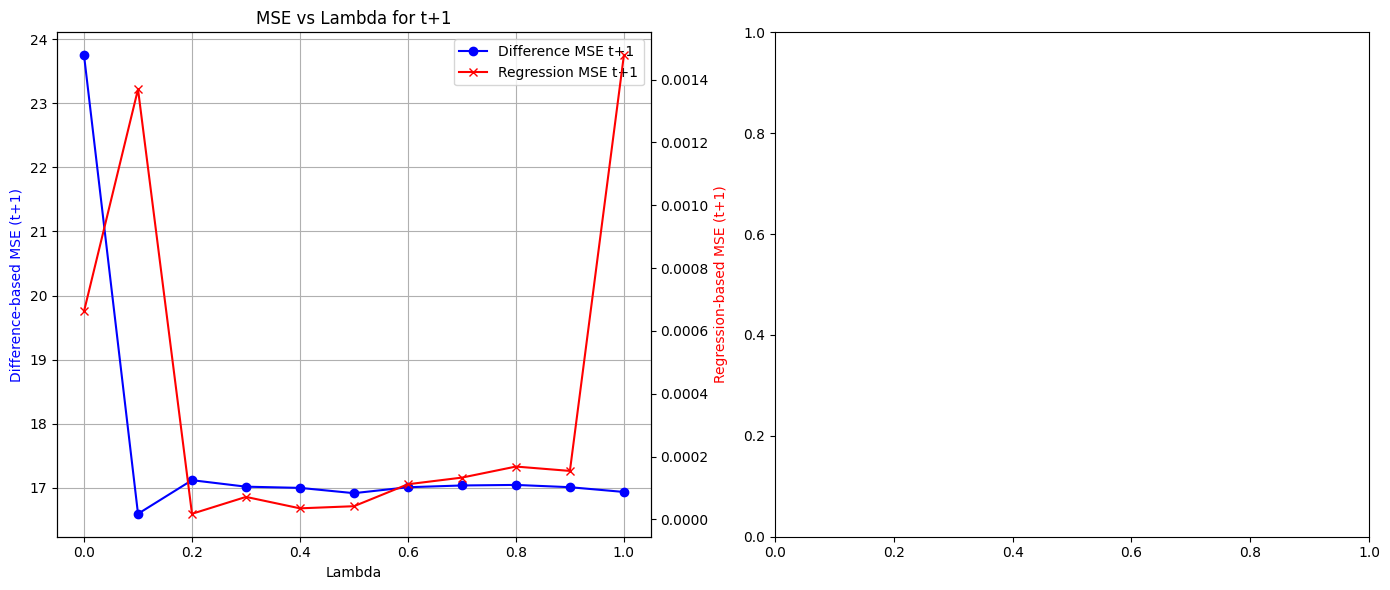

In [43]:

#@title Visualize results

import numpy as np
import matplotlib.pyplot as plt

# Adjustable flag: set True to remove lambda == 0 from the plots.
remove_zero = False

# Convert lambda_values to a numpy array (if not already)
lambda_values = np.array(lambda_values)

if remove_zero:
    mask = lambda_values != 0
    lambdas_plot = lambda_values[mask]
    mse_diff = np.array(mse_diff_list)[mask]
    mse_reg = np.array(mse_reg_list)[mask]

else:
    lambdas_plot = lambda_values
    mse_diff = mse_diff_list
    mse_reg = mse_reg_list


# Create a figure with two subplots: one for t+1 and one for t+2.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot for t+1 ---
ax1 = axes[0]
ax1_left = ax1  # left y-axis for difference-based MSE
ax1_right = ax1.twinx()  # right y-axis for regression-based MSE

ax1_left.plot(lambdas_plot, mse_diff, marker='o', color='blue', label='Difference MSE t+1')
ax1_right.plot(lambdas_plot, mse_reg, marker='x', color='red', label='Regression MSE t+1')

ax1_left.set_xlabel('Lambda')
ax1_left.set_ylabel('Difference-based MSE (t+1)', color='blue')
ax1_right.set_ylabel('Regression-based MSE (t+1)', color='red')
ax1_left.set_title('MSE vs Lambda for t+1')
ax1_left.grid(True)

# Combine legends
lines_left, labels_left = ax1_left.get_legend_handles_labels()
lines_right, labels_right = ax1_right.get_legend_handles_labels()
ax1_left.legend(lines_left + lines_right, labels_left + labels_right, loc='upper right')


plt.tight_layout()
plt.show()


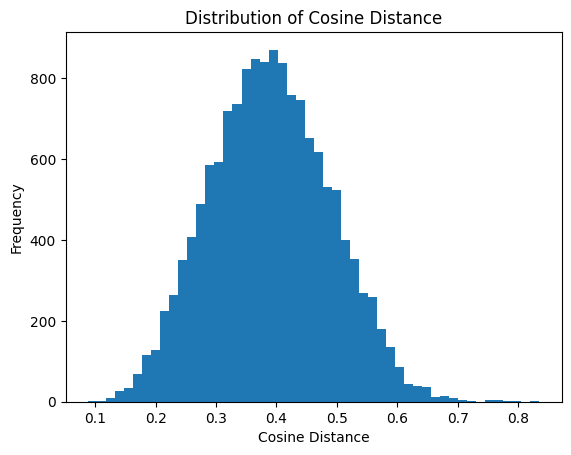

In [44]:
import matplotlib.pyplot as plt

# Assuming matches_df is your DataFrame with a 'cosine_distance' column
plt.hist(matched_df['cosine_distance'], bins=50)  # Adjust bins as needed
plt.title('Distribution of Cosine Distance')
plt.xlabel('Cosine Distance')
plt.ylabel('Frequency')
plt.show()

## Balance testing for combined matching

In [ ]:
#@title Load data

#@title Load Data
!pip install numpy pandas scipy scikit-learn sklearn tqdm cudf cupy

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm import tqdm
from scipy import stats
import cudf

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

## Load citations as cudf DataFrame from parquet.
citations = pd.read_parquet("/content/drive/MyDrive/PhD Data/08 Citations/02 Patent citations - raw.parquet")

## Load treated and control data as Pandas DataFrames so embeddings are preserved.
treated = pd.read_pickle("/content/drive/MyDrive/PhD Data/10 Sample - pre final/acquired_patents.pkl")
control = pd.read_pickle("/content/drive/MyDrive/PhD Data/10 Sample - pre final/potential_controls.pkl")

## Remove GAFAM patents
clean_potential_ids = pd.read_csv("/content/drive/MyDrive/PhD Data/10 Sample - pre final/clean_potential_control_ids.csv")
clean_set = set(clean_potential_ids['patent_id'].astype(str))

# Ensure the relevant columns are strings.
treated['patent_id'] = treated['patent_id'].astype(str)
treated['cpc_subclass'] = treated['cpc_subclass'].astype(str)
control['patent_id'] = control['patent_id'].astype(str)
control['cpc_subclass'] = control['cpc_subclass'].astype(str)

## Do not drop the embedding columns now, so we can use them for hybrid matching.

## Remove non-clean controls
control = control[control['patent_id'].isin(clean_set)]
assert len(control) == len(clean_potential_ids)

# TRIM CITATIONS DATA
# Only keep citations for patents that are either treated or control.
treated_ids = set(treated['patent_id'].unique())
control_ids = set(control['patent_id'].unique())
valid_ids = treated_ids.union(control_ids)
citations = citations[citations['patent_id'].isin(valid_ids)]
print("Trimmed citations shape:", citations.shape)

## Load the matched df
matches_df = load("/content/drive/MyDrive/PhD Data/11 Matches/03 Hybrid matches.pkl")


In [ ]:
#@title Precompute Treated Patent Quarterly Counts
import cudf
import pandas as pd
import numpy as np
import cudf
import pandas as pd
import numpy as np

# ================================================
# Step 1: Precompute Quarterly Citation Counts for All Patents (GPU version)
# ================================================
# Assume 'citations' is a cuDF DataFrame with columns:
#   - 'patent_id': the cited patent's ID
#   - 'citation_date': a datetime column

# Manually compute a quarter string: "YYYYQX"
citations['year'] = citations['citation_date'].dt.year
citations['month'] = citations['citation_date'].dt.month
# Compute quarter as integer: ((month-1)//3 + 1)
citations['qtr'] = ((citations['month'] - 1) // 3 + 1).astype(str)
citations['citation_quarter'] = citations['year'].astype(str) + "Q" + citations['qtr']

# Group by patent_id and citation_quarter to count citations per quarter.
# cuDF's groupby().size() returns a Series; unstack is not supported, so convert to pandas.
grouped = citations.groupby(['patent_id', 'citation_quarter']).size()
quarterly_counts_pd = grouped.unstack(fill_value=0)

# Build a dictionary mapping patent_id -> {quarter: count}
citation_counts_dict = {}
for pid, row in quarterly_counts_pd.iterrows():
    citation_counts_dict[pid] = row.to_dict()


# ================================================
# Step 2: Precompute Treated Patent Quarterly Vectors
# (Treated data is now a Pandas DataFrame with an 'embedding' column)
# ================================================

# Manually compute the acquisition quarter using pandas datetime methods.
treated['year'] = treated['acq_date'].dt.year
treated['month'] = treated['acq_date'].dt.month
treated['qtr'] = ((treated['month'] - 1) // 3 + 1).astype(str)
treated['acq_quarter'] = treated['year'].astype(str) + "Q" + treated['qtr']

# Build a dictionary mapping each treated patent_id to its pre-treatment quarterly vector.
# For each treated patent, define the four quarters immediately preceding its acquisition quarter.
treated_counts_dict = {}
for i, row in treated.iterrows():
    treated_id = row['patent_id']
    acq_period = pd.Period(row['acq_date'], freq='Q')
    # Pre-treatment quarters: four quarters immediately before acquisition.
    pre_quarters = [str(acq_period - j) for j in range(4, 0, -1)]
    # For each quarter, look up the citation count from citation_counts_dict (defaulting to 0 if missing).
    vec = [citation_counts_dict.get(treated_id, {}).get(q, 0) for q in pre_quarters]
    treated_counts_dict[treated_id] = {'pre_quarters': pre_quarters, 'vector': np.array(vec, dtype=float)}

# For example, print a few treated counts:
print("Example treated counts:")
for pid, info in list(treated_counts_dict.items())[:5]:
    print(pid, info)


### Tests for citations

In [ ]:
#@title Functions


###############################
# 5. Balance Tests on Matched Sample (Cumulative Citations)
###############################
# Copy matches to be used later
matches_copy = matches_df.copy()
matches_df = matches_df[0.4]
# Aggregate the 4-quarter vectors into cumulative citation counts.
matches_df['treated_total'] = matches_df['treated_vector'].apply(sum)
matches_df['control_total'] = matches_df['control_vector'].apply(sum)

# Compute control weights: frequency of each control_id.
control_weights = matches_df['control_id'].value_counts().to_dict()
matches_df['control_weight'] = matches_df['control_id'].map(control_weights).astype(float)

# Weighted SMD Calculation
def weighted_mean(x, w):
    return np.sum(x * w) / np.sum(w)

def weighted_variance(x, w):
    m = weighted_mean(x, w)
    return np.sum(w * (x - m)**2) / np.sum(w)

# Weighted KS Test (using unweighted treated ECDF and weighted control ECDF)
def weighted_ks_stat(treated_vals, control_vals, control_weights):
    all_vals = np.sort(np.unique(np.concatenate([treated_vals, control_vals])))
    n_treated = len(treated_vals)
    treated_ecdf = np.array([np.sum(treated_vals <= x) / n_treated for x in all_vals])
    total_weight = np.sum(control_weights)
    control_ecdf = np.array([np.sum(control_weights[control_vals <= x]) / total_weight for x in all_vals])
    return np.max(np.abs(treated_ecdf - control_ecdf))

In [ ]:
#@title SMD

treated_vals = matches_df['treated_total'].values.astype(float)
control_vals = matches_df['control_total'].values.astype(float)
control_w = matches_df['control_weight'].values.astype(float)

mean_treated = np.mean(treated_vals)
mean_control = weighted_mean(control_vals, control_w)
var_treated = np.var(treated_vals, ddof=1)
var_control = weighted_variance(control_vals, control_w)
pooled_sd = np.sqrt((var_treated + var_control) / 2)
smd = np.abs(mean_treated - mean_control) / pooled_sd

print("Weighted SMD (cumulative citations): {:.3f}".format(smd))

Weighted SMD (cumulative citations): 0.040


In [ ]:
#@title KS




ks_stat = weighted_ks_stat(treated_vals, control_vals, control_w)
print("Weighted KS statistic (cumulative citations): {:.3f}".format(ks_stat))

Weighted KS statistic (cumulative citations): 0.030


### Test for BERT embeddings

In [ ]:
#@title Functions

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --------- Helper Functions for Balance Tests ---------
def weighted_mean(x, w):
    return np.sum(x * w) / np.sum(w)

def weighted_variance(x, w):
    m = weighted_mean(x, w)
    return np.sum(w * (x - m)**2) / np.sum(w)

def compute_weighted_smd(treated_vals, control_vals, control_weights):
    """
    Compute the weighted Standardized Mean Difference (SMD)
    between treated and control values.
    """
    mean_t = np.mean(treated_vals)
    mean_c = weighted_mean(control_vals, control_weights)
    var_t = np.var(treated_vals, ddof=1)
    var_c = weighted_variance(control_vals, control_weights)
    pooled_sd = np.sqrt((var_t + var_c) / 2)
    return np.abs(mean_t - mean_c) / pooled_sd

def weighted_ks_stat(treated_vals, control_vals, control_weights):
    """
    Compute the weighted KS statistic comparing the unweighted ECDF
    of treated_vals and the weighted ECDF of control_vals.
    """
    treated_vals = np.asarray(treated_vals).flatten()
    control_vals = np.asarray(control_vals).flatten()
    control_weights = np.asarray(control_weights).flatten()
    all_vals = np.sort(np.unique(np.concatenate([treated_vals, control_vals])))
    n_treated = len(treated_vals)
    treated_ecdf = np.array([np.sum(treated_vals <= x) / n_treated for x in all_vals])
    total_weight = np.sum(control_weights)
    control_ecdf = np.array([np.sum(control_weights[control_vals <= x]) / total_weight for x in all_vals])
    return np.max(np.abs(treated_ecdf - control_ecdf))

# --------- Retrieve Embeddings from Matched Data ---------
# Assume df_bert_matches is the matched DataFrame from your BERT matching,
# with columns 'treated_id' and 'matched_id' (or 'control_id').
# Also assume that the original treated and control data (as Pandas DataFrames)
# have an 'embedding' column containing NumPy arrays.

def get_embedding(patent_id, df):
    # Returns the embedding for the given patent_id from df.
    return df.loc[df['patent_id'] == patent_id, 'embedding'].values[0]

In [ ]:
#@title Data
# Pre-index embeddings for treated and control patents
treated_emb_dict = treated.set_index('patent_id')['embedding'].to_dict()
control_emb_dict = control.set_index('patent_id')['embedding'].to_dict()

# Now iterate over matches_df and use dictionary lookups instead of iterrows on the full DataFrame.
treated_embeddings = []
control_embeddings = []

for idx, row in matches_df.iterrows():
    tid = row['treated_id']
    cid = row['control_id']
    treated_embeddings.append(treated_emb_dict.get(tid))
    control_embeddings.append(control_emb_dict.get(cid))

# Convert lists to numpy arrays.
treated_embeddings = np.stack(treated_embeddings)  # shape: (n_matches, dim)
control_embeddings = np.stack(control_embeddings)  # shape: (n_matches, dim)


In [ ]:
#@title Run PCA and Tests

# --------- Run PCA on the Combined Embeddings ---------
n_components = 25  # Adjust number of principal components as desired.
all_embeddings = np.vstack([treated_embeddings, control_embeddings])
pca = PCA(n_components=n_components)
pcs_all = pca.fit_transform(all_embeddings)

n_matches = treated_embeddings.shape[0]
treated_pcs = pcs_all[:n_matches, :]   # First n_matches rows: treated PCs
control_pcs = pcs_all[n_matches:, :]     # Remaining rows: control PCs

# --------- Retrieve Control Weights ---------
# Compute the weight (frequency) for each control in the matched sample.
control_weight_series = matches_df['control_id'].value_counts()
matches_df['control_weight'] = matches_df['control_id'].map(control_weight_series).astype(float)
control_weights = matches_df['control_weight'].values

# --------- Compute Balance Tests for Each Principal Component ---------
smd_pc = []
ks_pc = []

for j in range(n_components):
    t_vals = treated_pcs[:, j]
    c_vals = control_pcs[:, j]
    smd_j = compute_weighted_smd(t_vals, c_vals, control_weights)
    ks_j = weighted_ks_stat(t_vals, c_vals, control_weights)
    smd_pc.append(smd_j)
    ks_pc.append(ks_j)
    print(f"PC{j+1}: Weighted SMD = {smd_j:.3f}, Weighted KS = {ks_j:.3f}")

PC1: Weighted SMD = 0.037, Weighted KS = 0.043
PC2: Weighted SMD = 0.226, Weighted KS = 0.096
PC3: Weighted SMD = 0.040, Weighted KS = 0.023
PC4: Weighted SMD = 0.013, Weighted KS = 0.015
PC5: Weighted SMD = 0.111, Weighted KS = 0.056
PC6: Weighted SMD = 0.038, Weighted KS = 0.025
PC7: Weighted SMD = 0.025, Weighted KS = 0.024
PC8: Weighted SMD = 0.015, Weighted KS = 0.017
PC9: Weighted SMD = 0.039, Weighted KS = 0.034
PC10: Weighted SMD = 0.324, Weighted KS = 0.141
PC11: Weighted SMD = 0.042, Weighted KS = 0.034
PC12: Weighted SMD = 0.180, Weighted KS = 0.079
PC13: Weighted SMD = 0.124, Weighted KS = 0.057
PC14: Weighted SMD = 0.111, Weighted KS = 0.054
PC15: Weighted SMD = 0.036, Weighted KS = 0.036
PC16: Weighted SMD = 0.101, Weighted KS = 0.046
PC17: Weighted SMD = 0.024, Weighted KS = 0.028
PC18: Weighted SMD = 0.018, Weighted KS = 0.022
PC19: Weighted SMD = 0.101, Weighted KS = 0.047
PC20: Weighted SMD = 0.027, Weighted KS = 0.032
PC21: Weighted SMD = 0.034, Weighted KS = 0.017
P

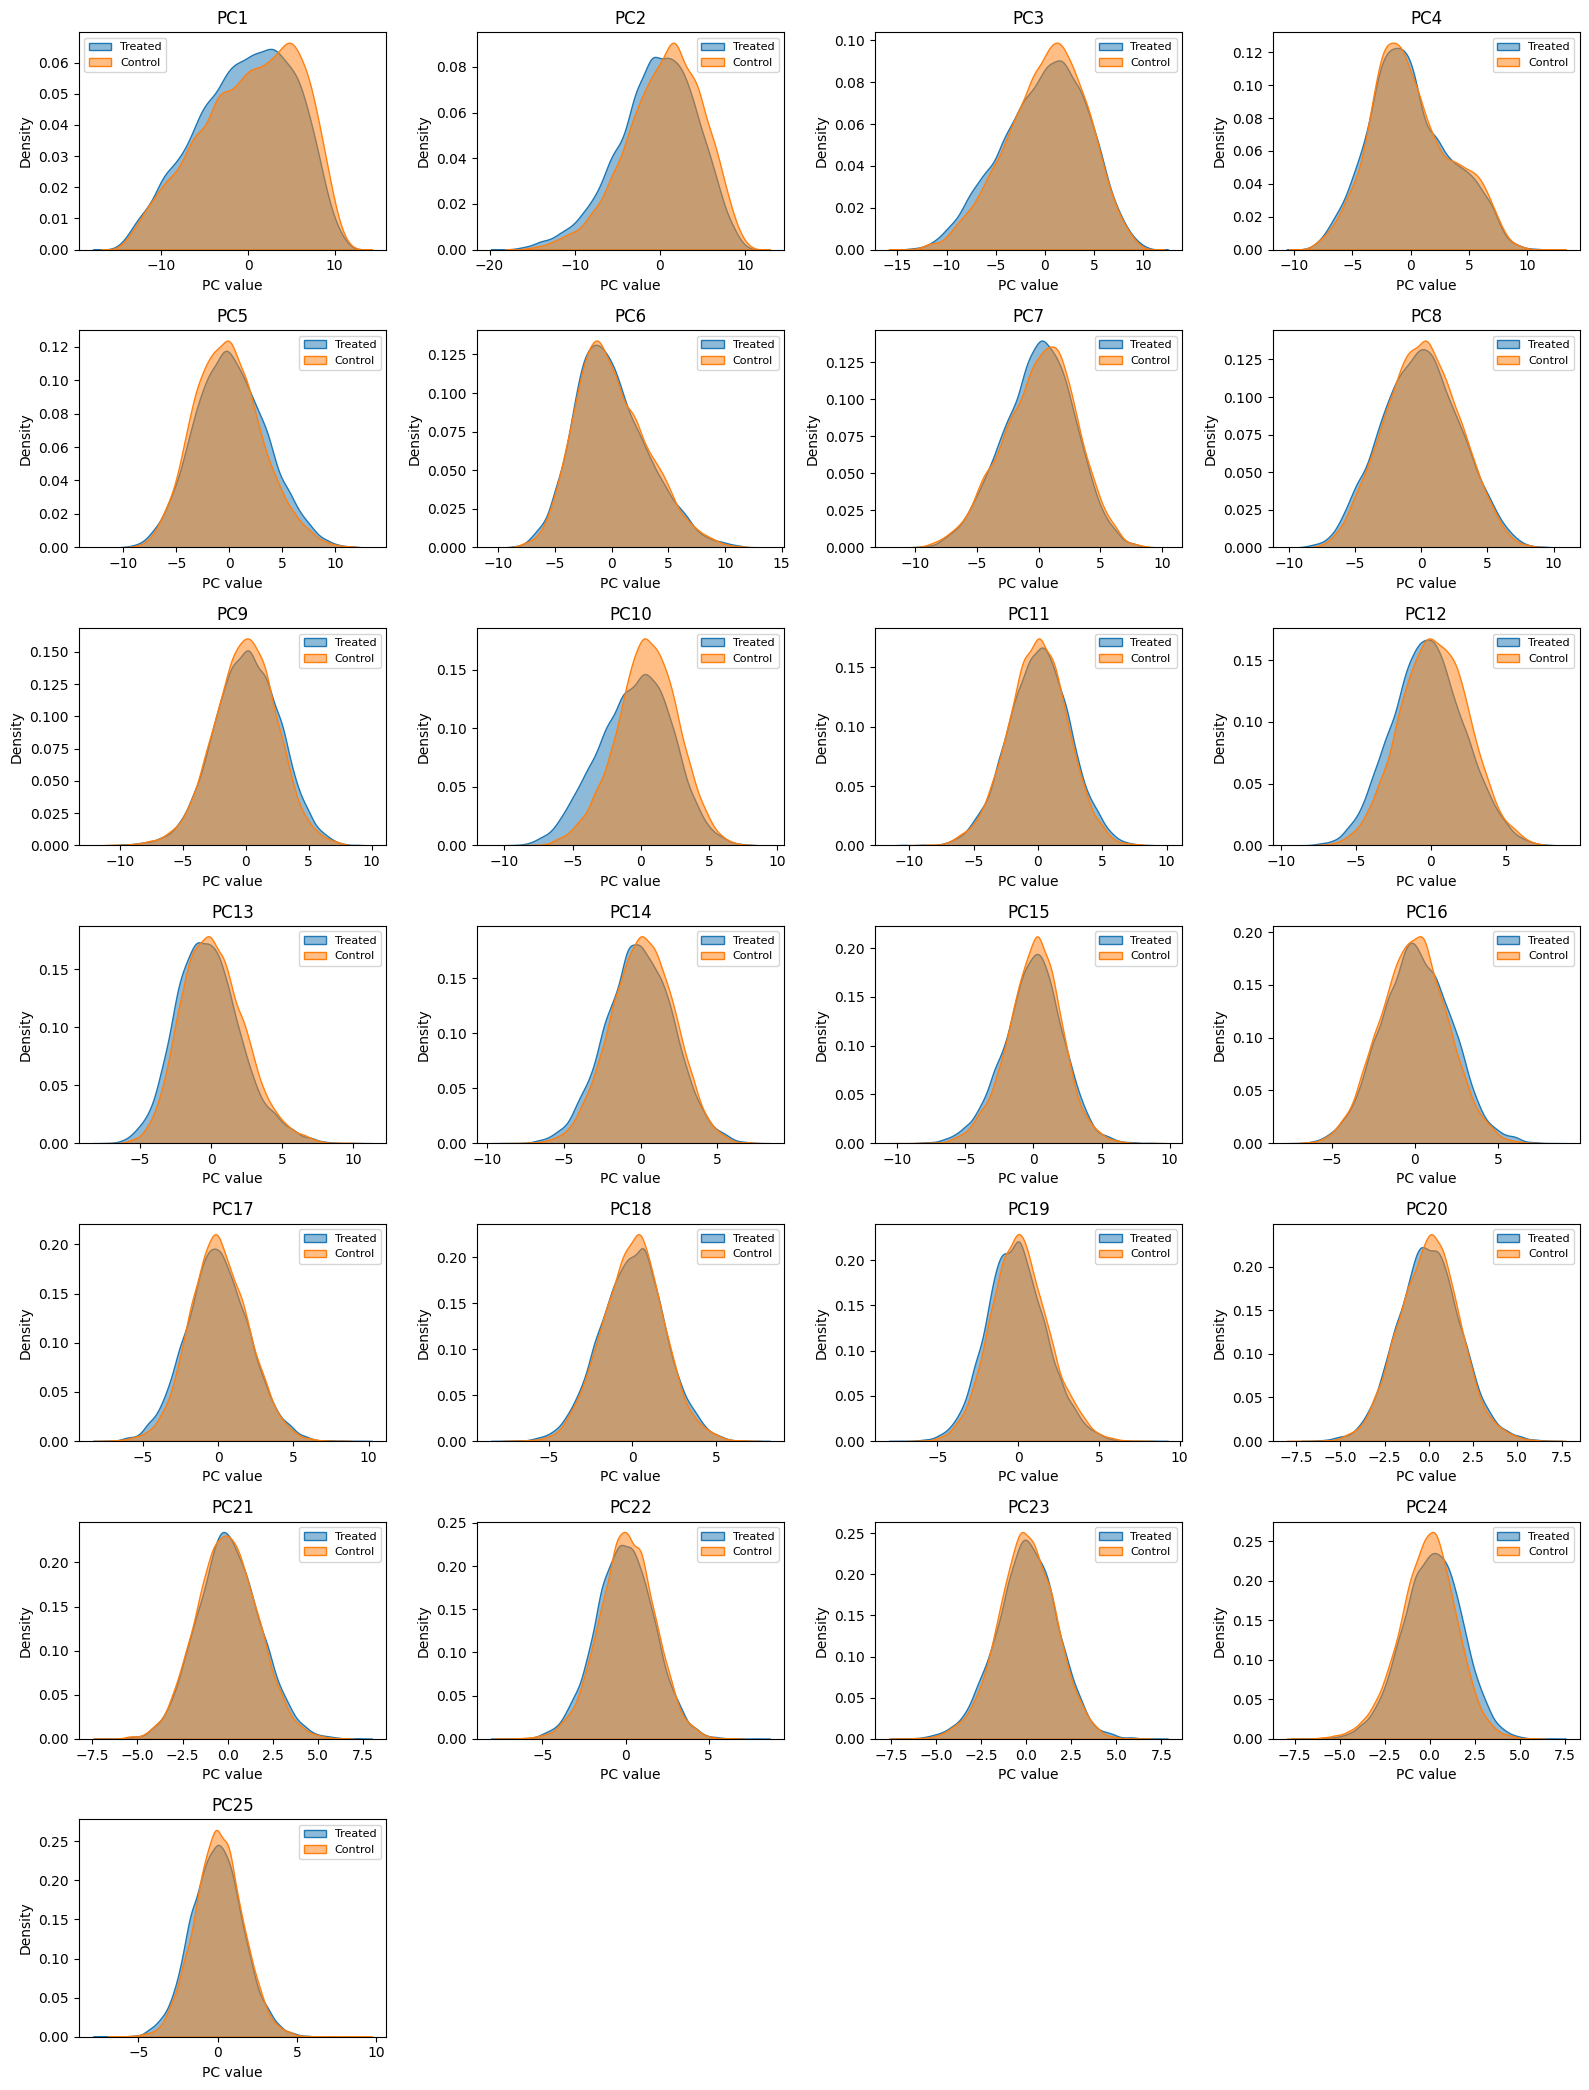

In [ ]:
#@title Plot


# --------- Plot the Balance Test Results ---------
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assume treated_pcs and control_pcs are numpy arrays of shape (n_matches, n_components)
# For example, they may have been computed earlier as:
#   n_matches = treated_embeddings.shape[0]
#   treated_pcs = pcs_all[:n_matches, :]
#   control_pcs = pcs_all[n_matches:, :]

n_components = treated_pcs.shape[1]

# Create a figure with subplots: adjust rows/cols as needed.
ncols = 4
nrows = int(np.ceil(n_components / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*4, nrows*3))
axes = axes.flatten()

for j in range(n_components):
    ax = axes[j]
    # Plot density for treated group.
    sns.kdeplot(treated_pcs[:, j], label='Treated', ax=ax, fill=True, alpha=0.5)
    # Plot density for control group.
    sns.kdeplot(control_pcs[:, j], label='Control', ax=ax, fill=True, alpha=0.5)
    ax.set_title(f'PC{j+1}')
    ax.set_xlabel('PC value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

# Remove extra subplots if any.
for k in range(j+1, len(axes)):
    fig.delaxes(axes[k])

plt.tight_layout()
plt.show()



In [ ]:
#2title Furhter checks of PCAs

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import statsmodels.api as sm

# -----------------------------------------------------
# Compute Cumulative Citation Counts
# -----------------------------------------------------
def get_cumulative_citations(pid, citation_dict):
    """Sum all quarterly citation counts for a given patent_id."""
    return sum(citation_counts_dict.get(pid, {}).values())

treated['cumulative_citations'] = treated['patent_id'].apply(lambda pid: get_cumulative_citations(pid, citation_counts_dict))

# -----------------------------------------------------
# Run PCA on BERT Embeddings
# -----------------------------------------------------
# Here we assume each 'embedding' is stored as a NumPy array.
embeddings = np.stack(treated['embedding'].values)  # shape: (n_patents, embedding_dim)

# Run PCA to obtain at least 10 principal components.
n_components = 25
pca = PCA(n_components=n_components)
pcs = pca.fit_transform(embeddings)  # shape: (n_patents, 10)

# Add PC10 to treated_emb (PC10 is the 10th column, index 9).
treated['PC10'] = pcs[:, 4]

# -----------------------------------------------------
# Regression: Cumulative Citations on PC10
# -----------------------------------------------------
# Standard notation:
#   Y_i = β₀ + β₁ PC10_i + ε_i,
# where Y_i = cumulative citations and PC10_i is the score on PC10.
X = treated['PC10']
X = sm.add_constant(X)  # adds an intercept term
y = treated['cumulative_citations']

model = sm.OLS(y, X).fit()
print(model.summary())


                             OLS Regression Results                             
Dep. Variable:     cumulative_citations   R-squared:                       0.005
Model:                              OLS   Adj. R-squared:                  0.005
Method:                   Least Squares   F-statistic:                     103.8
Date:                  Fri, 21 Mar 2025   Prob (F-statistic):           2.57e-24
Time:                          01:42:54   Log-Likelihood:            -1.1214e+05
No. Observations:                 19760   AIC:                         2.243e+05
Df Residuals:                     19758   BIC:                         2.243e+05
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         28.2402      0.502